Median correlation (left hemisphere, excluded tracts applied):
  SBI   : 0.920
  PRISM : 0.970


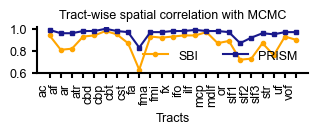

✅ Saved: tractwise_correlation_left_hemisphere_ICML_horizontal.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dmri.utils.viz import set_style
set_style("white")

# === File paths ===
tract_list_file = "list_tracts.txt"
sbi_file = "ICML_corr_MCMC_SBI.txt"
sbmi_file = "ICML_corr_MCMC_PRISM.txt"

# === Load tract names ===
with open(tract_list_file, "r") as f:
    tract_names = [line.strip() for line in f if line.strip()]

# === Load correlation values (skip 'NA') ===
def load_correlation_array(filepath):
    values = []
    with open(filepath, "r") as f:
        for line in f:
            val = line.strip()
            if val != "NA" and val != "":
                values.append(float(val))
            else:
                values.append(np.nan)
    return np.array(values)

sbi_corr = load_correlation_array(sbi_file)
sbmi_corr = load_correlation_array(sbmi_file)

# === Sanity check ===
assert len(tract_names) == len(sbi_corr) == len(sbmi_corr)

# === Left hemisphere filter ===
LEFT_SUFFIX = "_l"
MIDLINE_NAMES = {"ac", "mcp", "fx", "fmi", "fma"}  # add if needed
EXCLUDE_TRACTS = {}#"fa"}   # Tracts to exclude (base names, no _l / _r)

left_indices = [
    i for i, name in enumerate(tract_names)
    if name.endswith(LEFT_SUFFIX) or name in MIDLINE_NAMES
]

left_tracts = [
    tract_names[i].replace("_l", "") if tract_names[i].endswith("_l") else tract_names[i]
    for i in left_indices
]

sbi_left = sbi_corr[left_indices]
sbmi_left = sbmi_corr[left_indices]

# === Exclude selected tracts ===
keep_mask = [
    tract not in EXCLUDE_TRACTS
    for tract in left_tracts
]

left_tracts = [t for t, k in zip(left_tracts, keep_mask) if k]
sbi_left   = sbi_left[keep_mask]
sbmi_left  = sbmi_left[keep_mask]


# === Median correlations (after filtering) ===
sbi_median  = np.nanmedian(sbi_left)
sbmi_median = np.nanmedian(sbmi_left)

print("Median correlation (left hemisphere, excluded tracts applied):")
print(f"  SBI   : {sbi_median:.3f}")
print(f"  PRISM : {sbmi_median:.3f}")


# === Plot ===
plt.figure(figsize=(3.5, 0.6))  # auto width

x_pos = np.arange(len(left_tracts))

plt.plot(x_pos, sbi_left, 'o-', label='SBI',
         color='orange')
plt.plot(x_pos, sbmi_left, 's-', label='PRISM',
         color='#19198C')

plt.xticks(x_pos, left_tracts, rotation=90, ha='right')

plt.yticks([0.6, 0.8, 1.0])

plt.xlabel("Tracts")
#plt.ylabel("Corr. with MCMC")
plt.title("Tract-wise spatial correlation with MCMC")

#plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend(loc="lower right", ncol=2)
#plt.tight_layout()

# === Save ===
plt.savefig("tractwise_correlation_left_hemisphere_ICML_horizontal.png", dpi=300)
plt.savefig("tractwise_correlation_left_hemisphere_ICML_horizontal.svg")
plt.show()

print("✅ Saved: tractwise_correlation_left_hemisphere_ICML_horizontal.png")

In [7]:
np.mean(sbi_corr)

np.float64(0.8573809523809524)